## Coffee versus Power Nap

Cambiamo per un attimo il task. Proviamo a predire il tipo di intervento, dato che secondo noi questo è un dataset sintetico progettato per un solo task, ovvero predire tale variabile. 

In [59]:
from sklearn.preprocessing import LabelEncoder
from commons import logistic_model_selection, prepare_train_test, plot_confusion_matrix
import pandas as pd
import numpy as np
from sklearn.metrics import classification_report, confusion_matrix
from matplotlib import pyplot as plt
import seaborn as sns

from commons import prepare_train_test, logistic_model_selection, random_forest_model_selection
from commons import plot_confusion_matrix, plot_logistic_coefficients, plot_feature_importance

df = pd.read_csv('../power_nap_vs_coffee_effectiveness_dataset.csv')

#alertness_delta
df["alertness_delta"] = df["alertness_score_after"] - df["alertness_score_before"]
df = df.drop(["alertness_score_after", "alertness_score_before"], axis=1)

print(df["side_effects"].head()) # Qui i side_effects sono codificati come Grogginess, NaN, Anxiety, Crash

#encoding: dummies per le categorie non target, 0 e 1 per i tipi di intervento
df = pd.get_dummies(df, columns=["side_effects"])
le = LabelEncoder()
df["intervention_type"] = le.fit_transform(df["intervention_type"])
# elimino l'ID e la variabile dell'occupazione, che non sono informative,
#  ed elimino le righe con i NaN (i "No_side_effects")
df = df.drop(["participant_id","occupation"] ,axis=1)
# Introduco la X per poi poter fare le imputazioni più avanti
X = df.copy()
X = df.dropna()
# X.drop(subset=X["side_effects"])

#Controllo se l'intervento ha funzionato
X.head()

0    Grogginess
1           NaN
2       Anxiety
3         Crash
4    Grogginess
Name: side_effects, dtype: str


,age,sleep_hours_previous_night,intervention_type,intervention_duration_minutes,productivity_rating,mood_rating,alertness_delta,side_effects_Anxiety,side_effects_Crash,side_effects_Grogginess
0,24,5.4,1,15,5,10,15,False,False,True
1,37,5.6,1,30,6,5,16,False,False,False
2,32,4.4,0,30,2,5,8,True,False,False
3,28,6.9,0,30,4,6,11,False,True,False
4,25,4.7,1,30,3,6,18,False,False,True


In [60]:
X.columns

Index(['age', 'sleep_hours_previous_night', 'intervention_type',
       'intervention_duration_minutes', 'productivity_rating', 'mood_rating',
       'alertness_delta', 'side_effects_Anxiety', 'side_effects_Crash',
       'side_effects_Grogginess'],
      dtype='str')

In [61]:
y = X['intervention_type']
X = X.drop("intervention_type", axis=1)

Fitting 5 folds for each of 24 candidates, totalling 120 fits
              precision    recall  f1-score   support

           0       0.96      0.87      0.91        52
           1       0.87      0.96      0.91        48

    accuracy                           0.91       100
   macro avg       0.91      0.91      0.91       100
weighted avg       0.91      0.91      0.91       100


Accuratezza sul Train Set: 0.9274
Accuratezza sul Test Set: 0.9100
LogisticRegression(C=np.float64(1.0), max_iter=2000, penalty='l2',
                   random_state=42)

=== CONFUSION MATRIX ===
[[45  7]
 [ 2 46]]


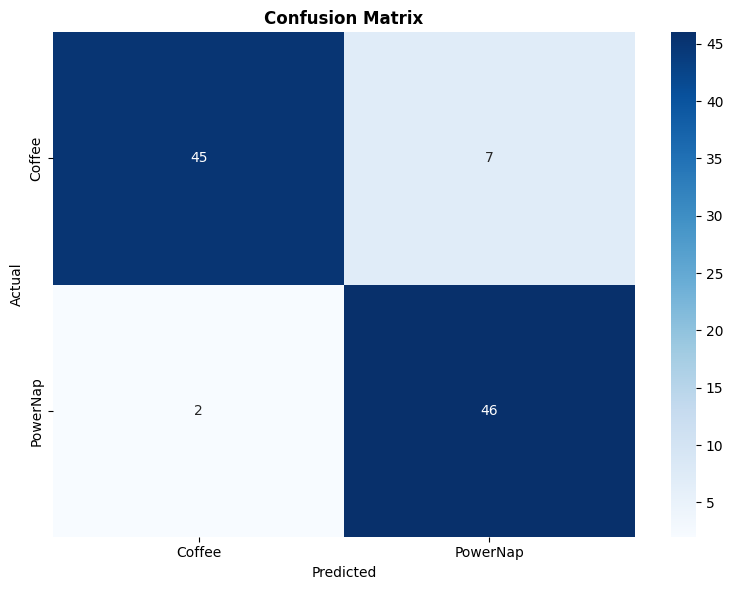

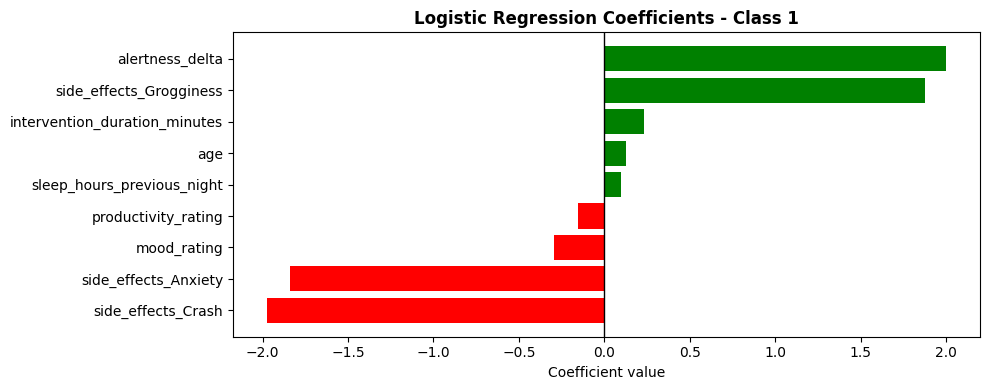

In [ ]:
import warnings
warnings.filterwarnings("ignore", message="Inconsistent values*")
warnings.filterwarnings("ignore", category=FutureWarning)

_, X_train, y_train, X_test, y_test = prepare_train_test(X, y)
logistic_regressor, best_params, best_score = logistic_model_selection(X_train, y_train)

y_pred = logistic_regressor.predict(X_test)
print(classification_report(y_test, y_pred))

# Accuratezza su train e test set
train_accuracy = logistic_regressor.score(X_train, y_train)
test_accuracy = logistic_regressor.score(X_test, y_test)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")
print(logistic_regressor.best_estimator_)  # Per vedere gli iperparametri scelti

cm = confusion_matrix(y_test, y_pred)
labels=['Coffee', 'PowerNap']
print("\n=== CONFUSION MATRIX ===")
print(cm)

plot_confusion_matrix(cm, labels, title="Confusion Matrix")
plot_logistic_coefficients(logistic_regressor.best_estimator_.coef_,X.columns,[logistic_regressor.best_estimator_.classes_[1]])
# Passiamo solo la (lista contenente la) classe positiva poiché per la classificazione binaria LogisticRegresssion calcola i
# coefficienti solo per questa. 



              precision    recall  f1-score   support

           0       0.98      0.83      0.90        52
           1       0.84      0.98      0.90        48

    accuracy                           0.90       100
   macro avg       0.91      0.90      0.90       100
weighted avg       0.91      0.90      0.90       100


Accuratezza sul Train Set: 0.9100
Accuratezza sul Test Set: 0.8998
RandomForestClassifier(class_weight='balanced_subsample', max_depth=3,
                       min_samples_leaf=20, min_samples_split=10,
                       n_estimators=50, random_state=42)

=== CONFUSION MATRIX ===
[[43  9]
 [ 1 47]]

=== CONFUSION MATRIX ===
[[43  9]
 [ 1 47]]


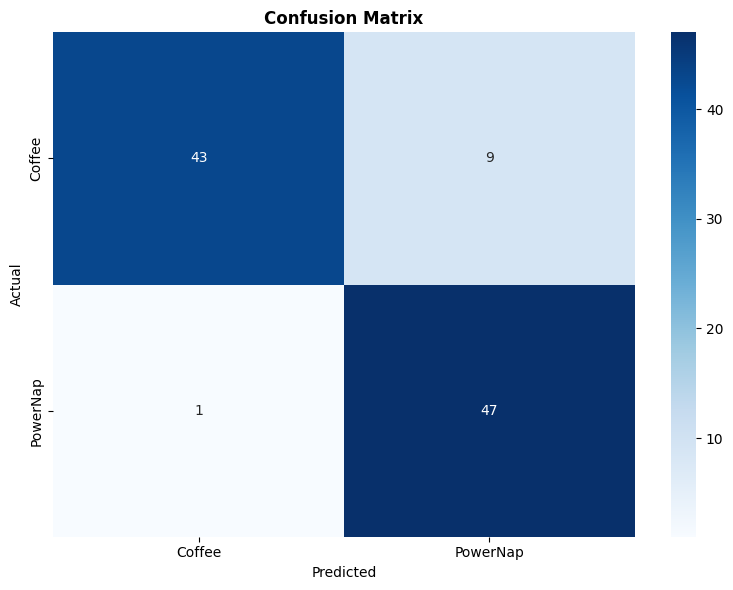

In [ ]:

rf_model, best_params, best_score = random_forest_model_selection(X_train, y_train)

y_pred = rf_model.predict(X_test)
print(classification_report(y_test, y_pred))

# Accuratezza su train e test set
train_accuracy = rf_model.score(X_train, y_train)
test_accuracy = rf_model.score(X_test, y_test)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")
print(rf_model.best_estimator_)  # Per vedere gli iperparametri scelti

cm = confusion_matrix(y_test, y_pred)
print("\n=== CONFUSION MATRIX ===")
print(cm)

cm = confusion_matrix(y_test, y_pred)
labels=['Coffee', 'PowerNap']
print("\n=== CONFUSION MATRIX ===")
print(cm)

plot_confusion_matrix(cm, labels, title="Confusion Matrix")


Feature Importance:
                         Feature  Importance
5                alertness_delta    0.323947
8        side_effects_Grogginess    0.288580
7             side_effects_Crash    0.226305
6           side_effects_Anxiety    0.128101
1     sleep_hours_previous_night    0.011260
4                    mood_rating    0.009832
3            productivity_rating    0.006469
0                            age    0.004310
2  intervention_duration_minutes    0.001196


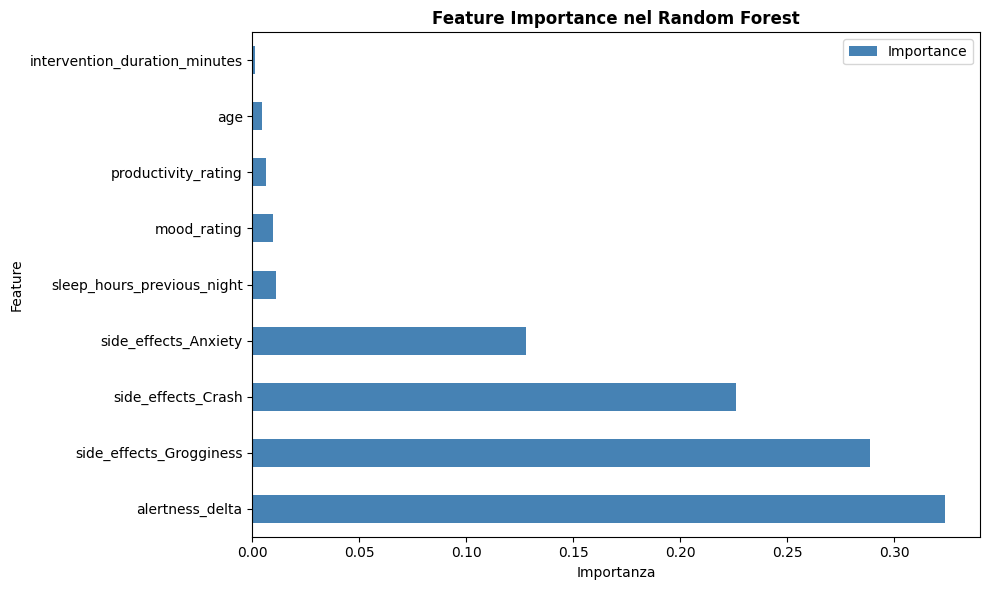

In [64]:
plot_feature_importance(rf_model.best_estimator_.feature_importances_,X.columns)

# Imputazioni

Ora proviamo a sfruttare i modelli allenati sui dati con side effect (scartando le variabili relative all'occupazione) e con target i side effect per effettuare le imputazioni sui dati mancanti relative ai side effects.


In [ ]:
# Ridefiniamo df, perché non vogliamo un one-hot encoding per side_effects
df = pd.read_csv('../power_nap_vs_coffee_effectiveness_dataset.csv')
# Identifichiamo le colonne numeriche da lasciare, eliminando l'occupation type e l'identity
df = df.drop(['occupation', "participant_id"], axis=1)


In [66]:
df["side_effects"].head()

0    Grogginess
1           NaN
2       Anxiety
3         Crash
4    Grogginess
Name: side_effects, dtype: str

In [67]:
side_effects_dict = {'No side effects':3, 'Grogginess':2, 'Crash':1, 'Anxiety':0}
rev_side_effects_dict = {3:'No side effects', 2:'Grogginess', 1:'Crash', 0:'Anxiety'}

In [ ]:
# Alleniamo i modelli sui dati con side effects presenti, avendo come target i side effects
X_imp = df.copy()
X_imp = X_imp.dropna()
y_imp = X_imp["side_effects"]
X_imp = X_imp.drop("side_effects", axis=1)

# Trasforma intervention_type in valori numerici
le_imp = LabelEncoder()
X_imp["intervention_type"] = le_imp.fit_transform(X_imp["intervention_type"]) 

y_imp = y_imp.map(side_effects_dict)

In [69]:
# Separa e scala separatamente i dati in training e test set
_, X_train_imp, y_train_imp, X_test_imp, y_test_imp = prepare_train_test(X_imp, y_imp) 

Fitting 5 folds for each of 24 candidates, totalling 120 fits
              precision    recall  f1-score   support

           0       0.40      0.67      0.50        15
           1       0.50      0.25      0.33        20
           2       1.00      1.00      1.00        24

    accuracy                           0.66        59
   macro avg       0.63      0.64      0.61        59
weighted avg       0.68      0.66      0.65        59


Accuratezza sul Train Set: 0.7417
Accuratezza sul Test Set: 0.6111
LogisticRegression(C=np.float64(1.0), class_weight='balanced', max_iter=2000,
                   penalty='l2', random_state=42)

=== CONFUSION MATRIX ===
[[10  5  0]
 [15  5  0]
 [ 0  0 24]]


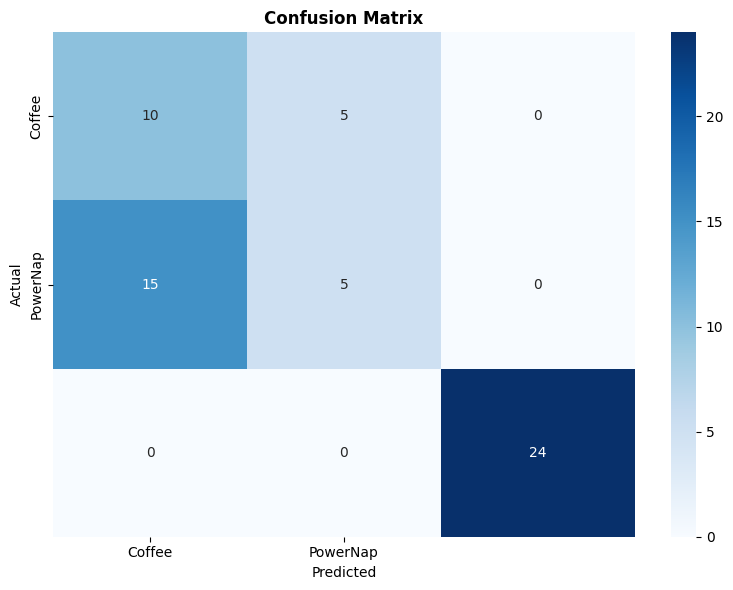

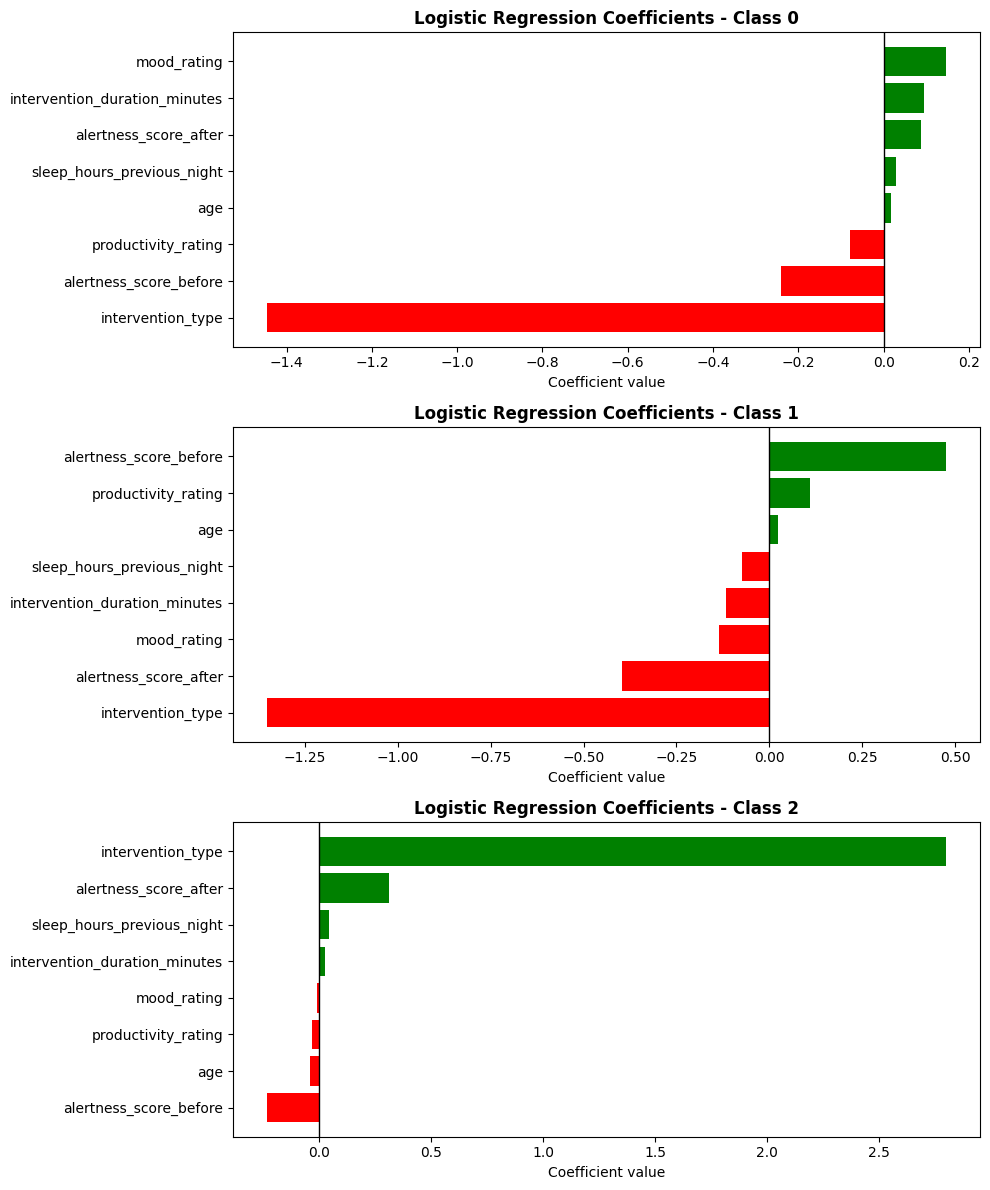

In [ ]:
logistic_regressor, best_params, best_score = logistic_model_selection(X_train_imp, y_train_imp)

y_pred_imp = logistic_regressor.predict(X_test_imp)
print(classification_report(y_test_imp, y_pred_imp))

# Accuratezza su train e test set
train_accuracy = logistic_regressor.score(X_train_imp, y_train_imp)
test_accuracy = logistic_regressor.score(X_test_imp, y_test_imp)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")
print(logistic_regressor.best_estimator_)  # Per vedere gli iperparametri scelti

cm = confusion_matrix(y_test_imp, y_pred_imp)
labels=['Coffee', 'PowerNap']
print("\n=== CONFUSION MATRIX ===")
print(cm)

plot_confusion_matrix(cm, labels, title="Confusion Matrix")
plot_logistic_coefficients(logistic_regressor.best_estimator_.coef_,X_imp.columns, logistic_regressor.best_estimator_.classes_)

              precision    recall  f1-score   support

           0       0.32      0.40      0.35        15
           1       0.44      0.35      0.39        20
           2       1.00      1.00      1.00        24

    accuracy                           0.63        59
   macro avg       0.58      0.58      0.58        59
weighted avg       0.64      0.63      0.63        59


Accuratezza sul Train Set: 0.8976
Accuratezza sul Test Set: 0.5806
RandomForestClassifier(class_weight='balanced_subsample', max_depth=5,
                       min_samples_leaf=5, min_samples_split=10,
                       n_estimators=150, random_state=42)

=== CONFUSION MATRIX ===
[[ 6  9  0]
 [13  7  0]
 [ 0  0 24]]

=== CONFUSION MATRIX ===
[[ 6  9  0]
 [13  7  0]
 [ 0  0 24]]


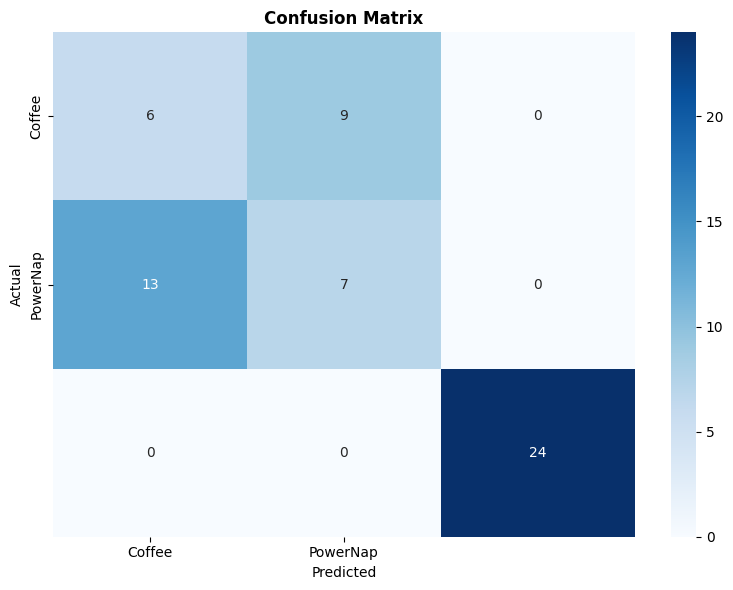

In [ ]:
rf_model, best_params, best_score = random_forest_model_selection(X_train_imp, y_train_imp)

y_pred_imp = rf_model.predict(X_test_imp)
print(classification_report(y_test_imp, y_pred_imp))

# Accuratezza su train e test set
train_accuracy = rf_model.score(X_train_imp, y_train_imp)
test_accuracy = rf_model.score(X_test_imp, y_test_imp)

print(f"\nAccuratezza sul Train Set: {train_accuracy:.4f}")
print(f"Accuratezza sul Test Set: {test_accuracy:.4f}")
print(rf_model.best_estimator_)  # Per vedere gli iperparametri scelti

cm = confusion_matrix(y_test_imp, y_pred_imp)
print("\n=== CONFUSION MATRIX ===")
print(cm)

cm = confusion_matrix(y_test_imp, y_pred_imp)
labels=['Coffee', 'PowerNap']
print("\n=== CONFUSION MATRIX ===")
print(cm)

plot_confusion_matrix(cm, labels, title="Confusion Matrix")

Feature Importance:
                         Feature  Importance
2              intervention_type    0.594983
5          alertness_score_after    0.078153
1     sleep_hours_previous_night    0.077240
4         alertness_score_before    0.075111
6            productivity_rating    0.054947
7                    mood_rating    0.048249
0                            age    0.047680
3  intervention_duration_minutes    0.023637


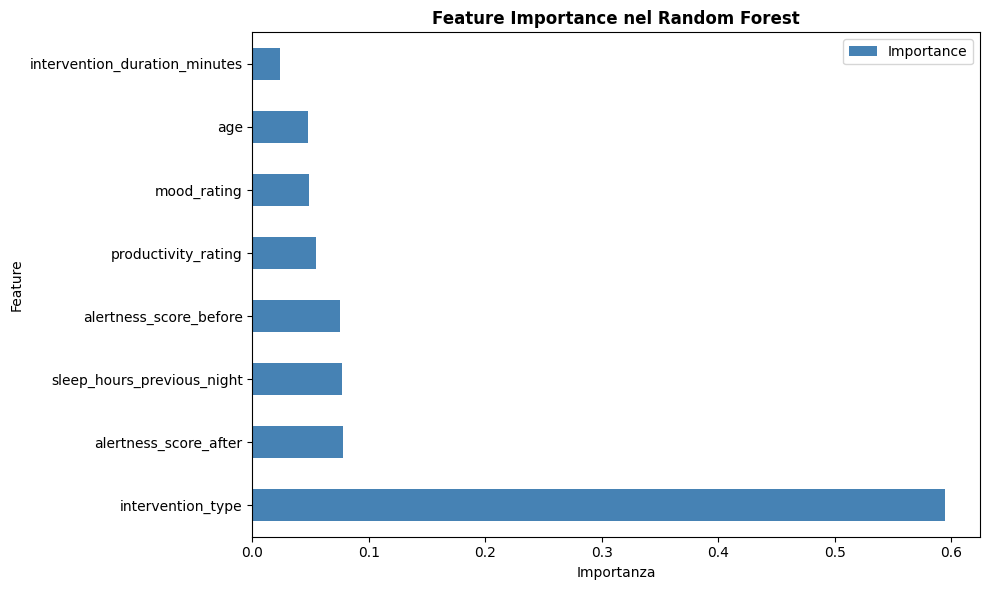

In [72]:
plot_feature_importance(rf_model.best_estimator_.feature_importances_,X_imp.columns)

In [ ]:
# Imputazioni con la regressione logistica
df_reglog = df.copy()
df_reglog["intervention_type"] = le_imp.transform(df_reglog["intervention_type"])  

missing_mask = df_reglog["side_effects"].isna()
if missing_mask.any(): # Se ci sono NaN
    y_pred_log_numeric = logistic_regressor.predict(df_reglog.loc[missing_mask].drop("side_effects", axis=1).to_numpy())
    # Riconvertiamo le predizioni numeriche in label di tipo string
    y_pred_log_strings = pd.Series(y_pred_log_numeric).map(rev_side_effects_dict)
    df_reglog.loc[missing_mask, "side_effects"] = y_pred_log_strings.values

In [74]:
df_reglog.columns

Index(['age', 'sleep_hours_previous_night', 'intervention_type',
       'intervention_duration_minutes', 'alertness_score_before',
       'alertness_score_after', 'productivity_rating', 'mood_rating',
       'side_effects'],
      dtype='str')

In [75]:
X_imp.columns

Index(['age', 'sleep_hours_previous_night', 'intervention_type',
       'intervention_duration_minutes', 'alertness_score_before',
       'alertness_score_after', 'productivity_rating', 'mood_rating'],
      dtype='str')

In [ ]:
# Imputazioni con la random forest
df_rf = df.copy()
df_rf["intervention_type"] = le_imp.transform(df_rf["intervention_type"])  

missing_mask = df_rf["side_effects"].isna()
if missing_mask.any(): # Se ci sono NaN
    y_pred_rf_numeric = rf_model.predict(df_rf.loc[missing_mask].drop("side_effects", axis=1).to_numpy())
    # Riconvertiamo le predizioni numeriche in label di tipo string
    y_pred_rf_strings = pd.Series(y_pred_rf_numeric).map(rev_side_effects_dict)
    df_rf.loc[missing_mask, "side_effects"] = y_pred_rf_strings.values

Imputazioni con regressione logistica:

<Figure size 1200x700 with 0 Axes>

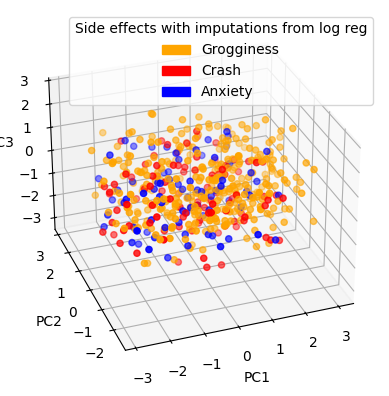

In [ ]:
# Visualizzazione 3D
from sklearn.decomposition import PCA
import matplotlib.patches as mpatches
from sklearn.preprocessing import StandardScaler
# Prepariamo i dati per la PCA

X = df_reglog.copy()  # Imputazioni con regressione logistica
df_y = X["side_effects"]
X.drop(["side_effects"], axis=1, inplace=True)


scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

#3D scatter plot
pcan = PCA(n_components=3)
pc_np = pcan.fit_transform(X_scaled)

fig = plt.figure(figsize=(12,7))
ax = plt.figure().add_subplot(projection='3d')

cmap = {'Grogginess':'orange', 'Crash':'red', 'Anxiety':'blue'}

ax.scatter(pc_np[:,0], pc_np[:,1], pc_np[:,2], c=[cmap.get(c, 'gray') for c in df_y.values], marker='o', s=20)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(30,-110)
handles = [mpatches.Patch(color=color, label=label) for label, color in cmap.items()]
ax.legend(handles=handles, title='Side effects with imputations from log reg')
plt.show()

<Figure size 1200x700 with 0 Axes>

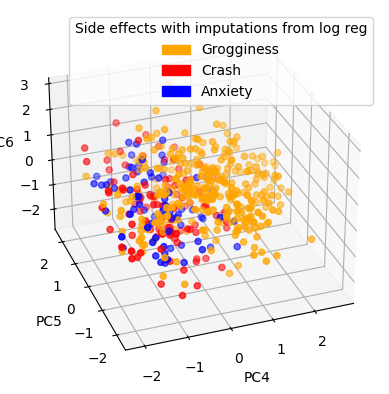

In [78]:
#3D scatter plot
pcan = PCA(n_components=6)
pc_np = pcan.fit_transform(X_scaled)

fig = plt.figure(figsize=(12,7))
ax = plt.figure().add_subplot(projection='3d')

cmap = {'Grogginess':'orange', 'Crash':'red', 'Anxiety':'blue'}

ax.scatter(pc_np[:,3], pc_np[:,4], pc_np[:,5], c=[cmap.get(c, 'gray') for c in df_y.values], marker='o', s=20)

ax.set_xlabel('PC4')
ax.set_ylabel('PC5')
ax.set_zlabel('PC6')
ax.view_init(30,-110)
handles = [mpatches.Patch(color=color, label=label) for label, color in cmap.items()]
ax.legend(handles=handles, title='Side effects with imputations from log reg')
plt.show()

Imputazioni con random forest:

<Figure size 1200x700 with 0 Axes>

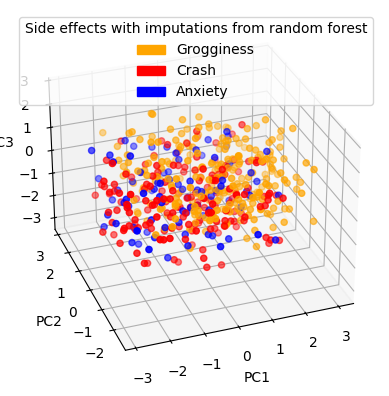

In [79]:
# Visualizzazione 3D
#3D scatter plot
# Preparo i dati per la PCA

X = df_rf.copy()  # Imputazioni con random forest
df_y = X["side_effects"]
X.drop(["side_effects"], axis=1, inplace=True)

scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)
pcan = PCA(n_components=3)
pc_np = pcan.fit_transform(X_scaled)

fig = plt.figure(figsize=(12,7))
ax = plt.figure().add_subplot(projection='3d')

cmap = {'Grogginess':'orange', 'Crash':'red', 'Anxiety':'blue'}

ax.scatter(pc_np[:,0], pc_np[:,1], pc_np[:,2], c=[cmap.get(c, 'gray') for c in df_y.values], marker='o', s=20)

ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_zlabel('PC3')
ax.view_init(30,-110)
handles = [mpatches.Patch(color=color, label=label) for label, color in cmap.items()]
ax.legend(handles=handles, title='Side effects with imputations from random forest')
plt.show()

<Figure size 1200x700 with 0 Axes>

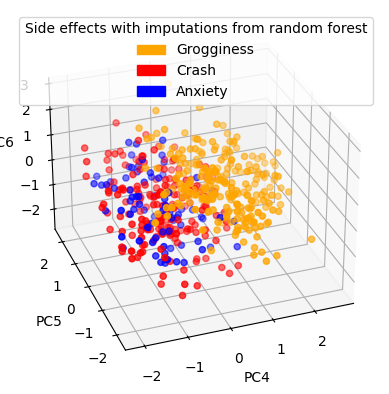

In [80]:
# Visualizzazione 3D
#3D scatter plot
# Preparo i dati per la PCA

pcan = PCA(n_components=6)
pc_np = pcan.fit_transform(X_scaled)

fig = plt.figure(figsize=(12,7))
ax = plt.figure().add_subplot(projection='3d')

cmap = {'Grogginess':'orange', 'Crash':'red', 'Anxiety':'blue'}

ax.scatter(pc_np[:,3], pc_np[:,4], pc_np[:,5], c=[cmap.get(c, 'gray') for c in df_y.values], marker='o', s=20)

ax.set_xlabel('PC4')
ax.set_ylabel('PC5')
ax.set_zlabel('PC6')
ax.view_init(30,-110)
handles = [mpatches.Patch(color=color, label=label) for label, color in cmap.items()]
ax.legend(handles=handles, title='Side effects with imputations from random forest')
plt.show()